# Figure 6 - Nongenic/Antisense Transcripts Panel

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.sgd import read_nondubious_genes_dataset
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genes = read_nondubious_genes_dataset()
gene = genes[genes['gene'] == 'HTA1'].iloc[0]

genome_deconv_analysis = GenomeDeconvolutionAnalysis(
    'output/draft4_run/', 
    'output/draft4_run/chromatin_deconvolution/deconvolution_data/')
span = gene.start-2000, gene.stop+2000
loaded_data = genome_deconv_analysis.load_mnase_span(gene.chr, span)


In [4]:
from src.transcript_boundary_caller import TranscriptBoundaryCaller
from src.timer import Timer

caller = TranscriptBoundaryCaller(output_directory='output/draft4_run/')
caller.set_chrom_span(gene.chr, span)

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 4
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr4.h5, crick_rna_seq_pileup_rep1_chr4.h5
Shape: (16, 1531933) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr4.h5, crick_rna_seq_pileup_rep2_chr4.h5
Shape: (14, 1531933) (timepoints x positions)


In [5]:
from src.orf_plotter import load_default_orf_plotter
from src.rna_pileup_plotter import RNASeqPileupPlotter
from src.combined_chromatin_model import CombinedChromatinModel
from src.config import load_default_chrom_configs

outdir = 'output/draft4_run/'
config1, config2 = load_default_chrom_configs()
orf_plotter = load_default_orf_plotter()
rna_plotter = RNASeqPileupPlotter(outdir)
combined_model = CombinedChromatinModel(config1=config1, config2=config2)    

In [6]:
caller.call_boundaries_both_strands()

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 4
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr4.h5, crick_rna_seq_pileup_rep1_chr4.h5
Shape: (16, 1531933) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr4.h5, crick_rna_seq_pileup_rep2_chr4.h5
Shape: (14, 1531933) (timepoints x positions)
Loading chromosome reads: 4
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupan

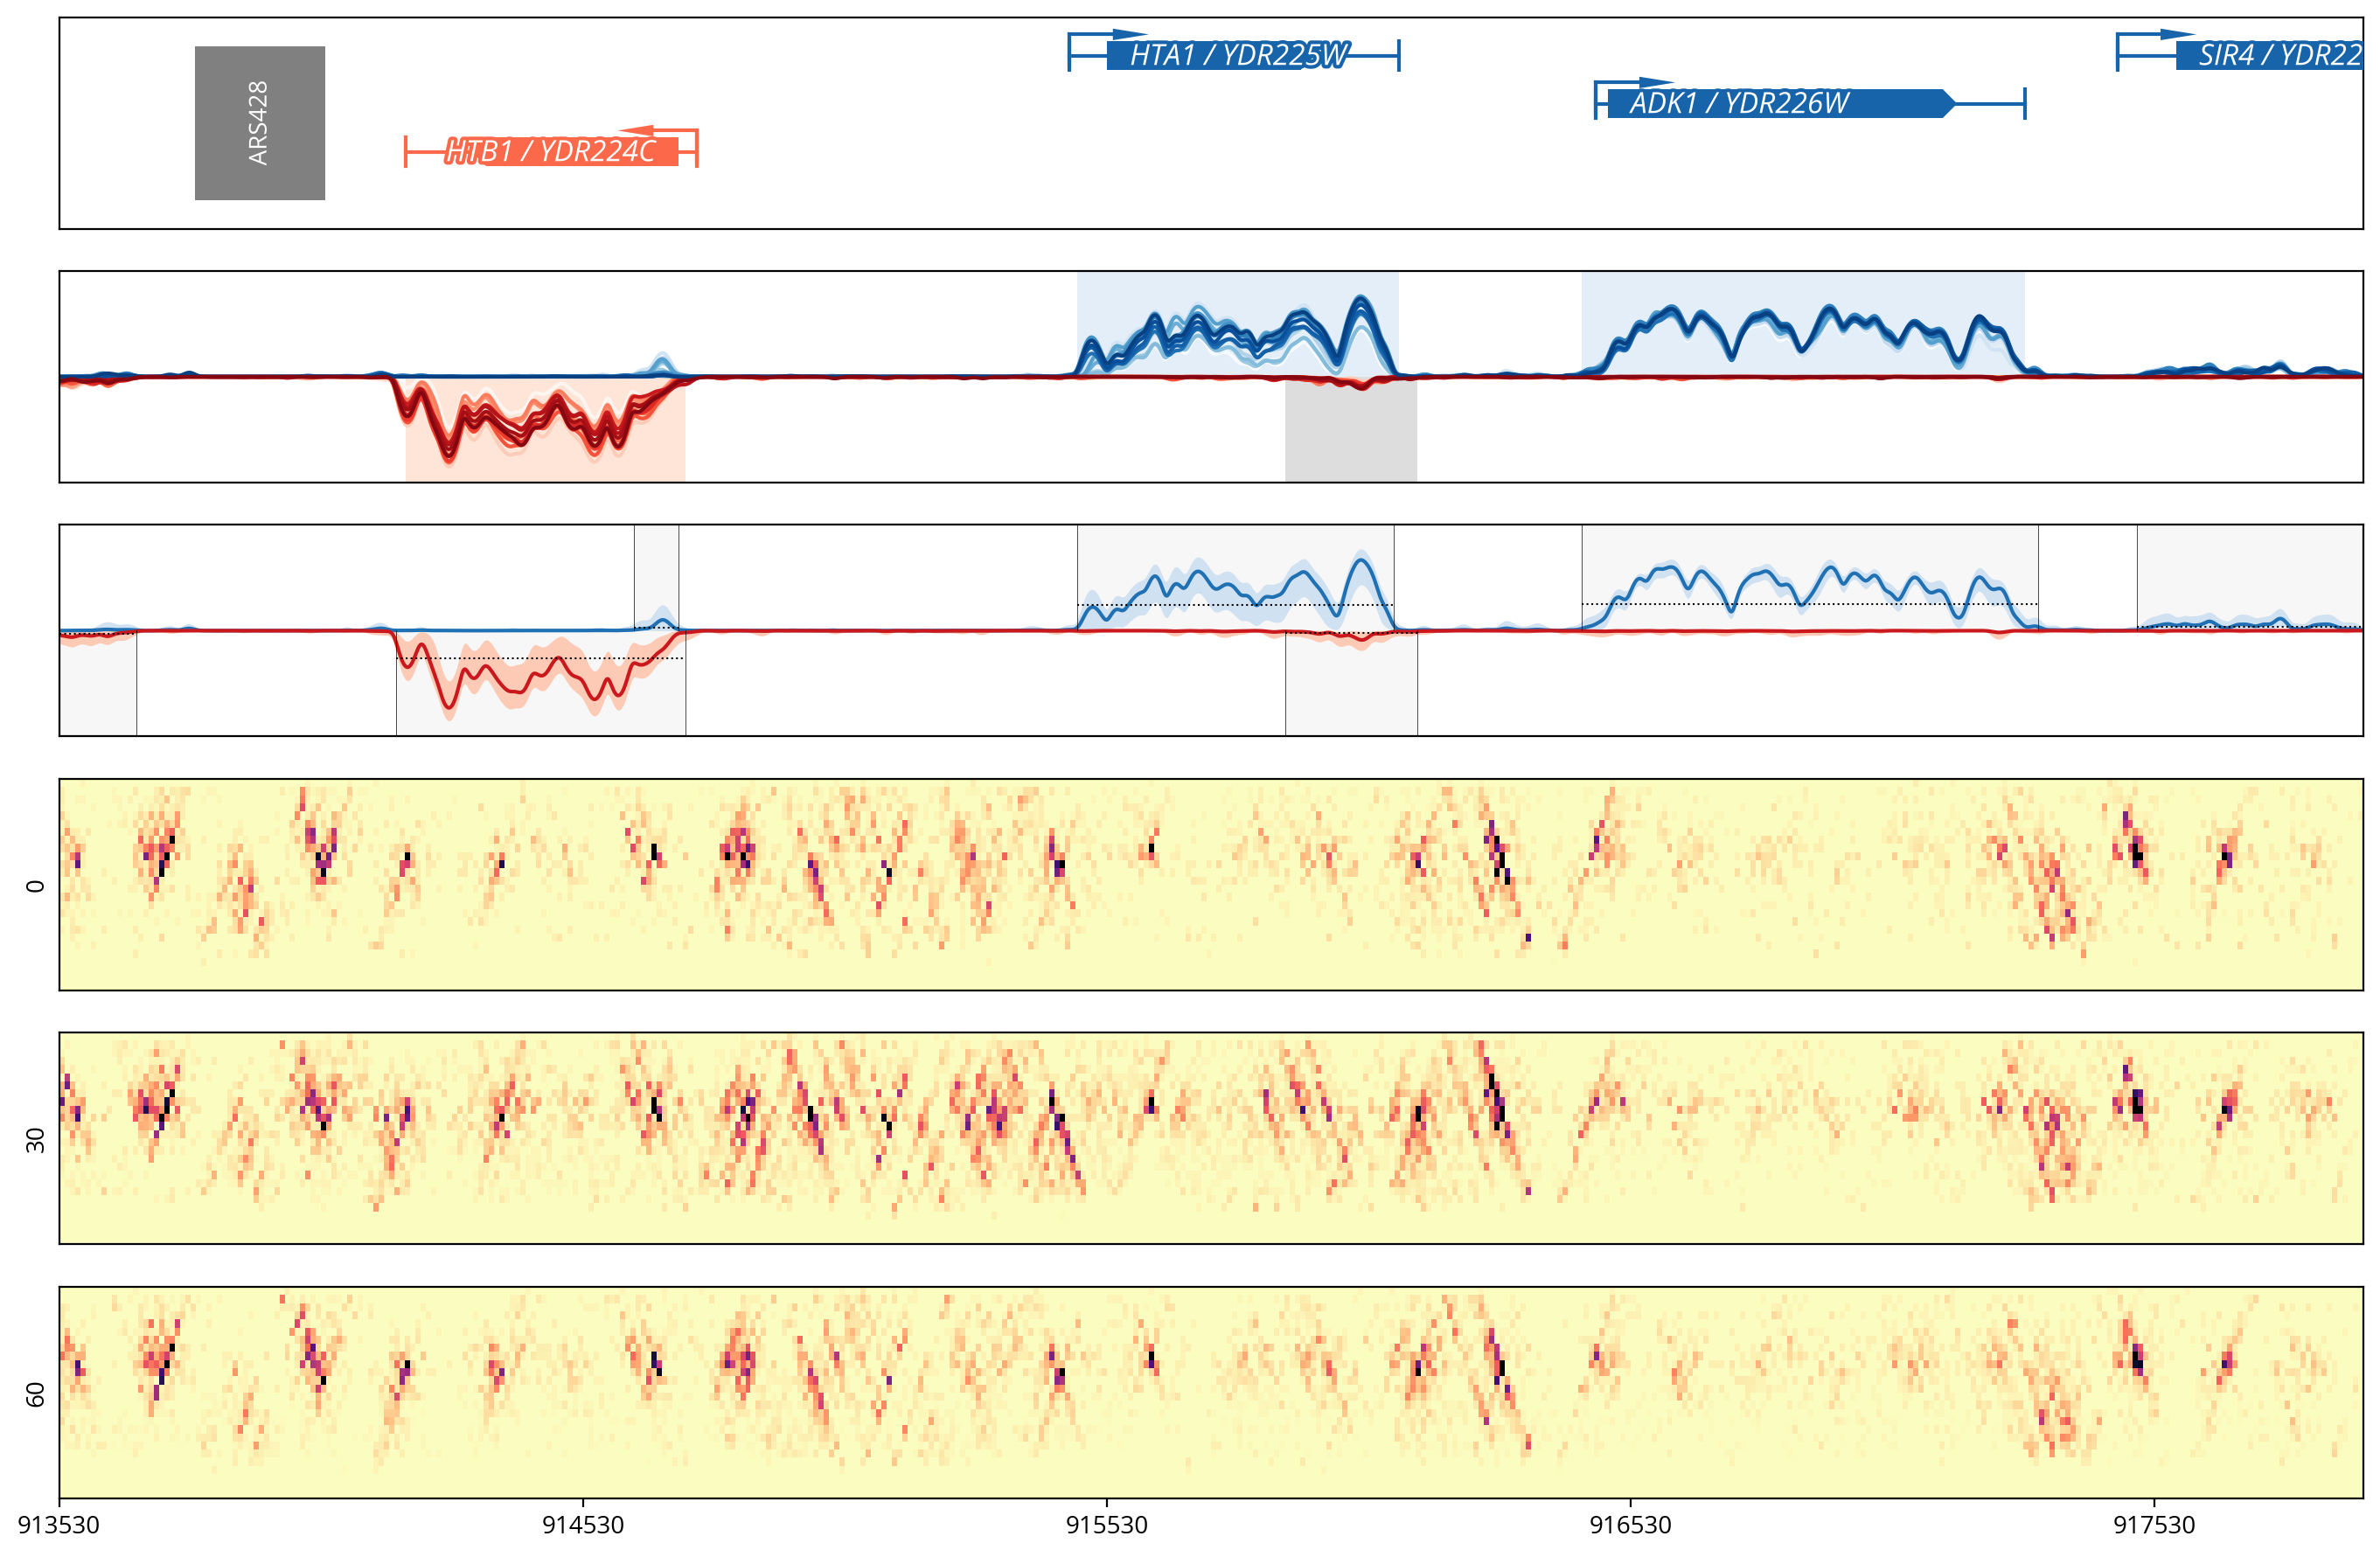

In [7]:
from src.transcript_boundary_visualizer import plot_tx_transcript_context

plot_tx_transcript_context(outdir, gene.chr, span, orf_plotter, rna_plotter, 
                           combined_model, caller)

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 4
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr4.h5, crick_rna_seq_pileup_rep1_chr4.h5
Shape: (16, 1531933) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr4.h5, crick_rna_seq_pileup_rep2_chr4.h5
Shape: (14, 1531933) (timepoints x positions)


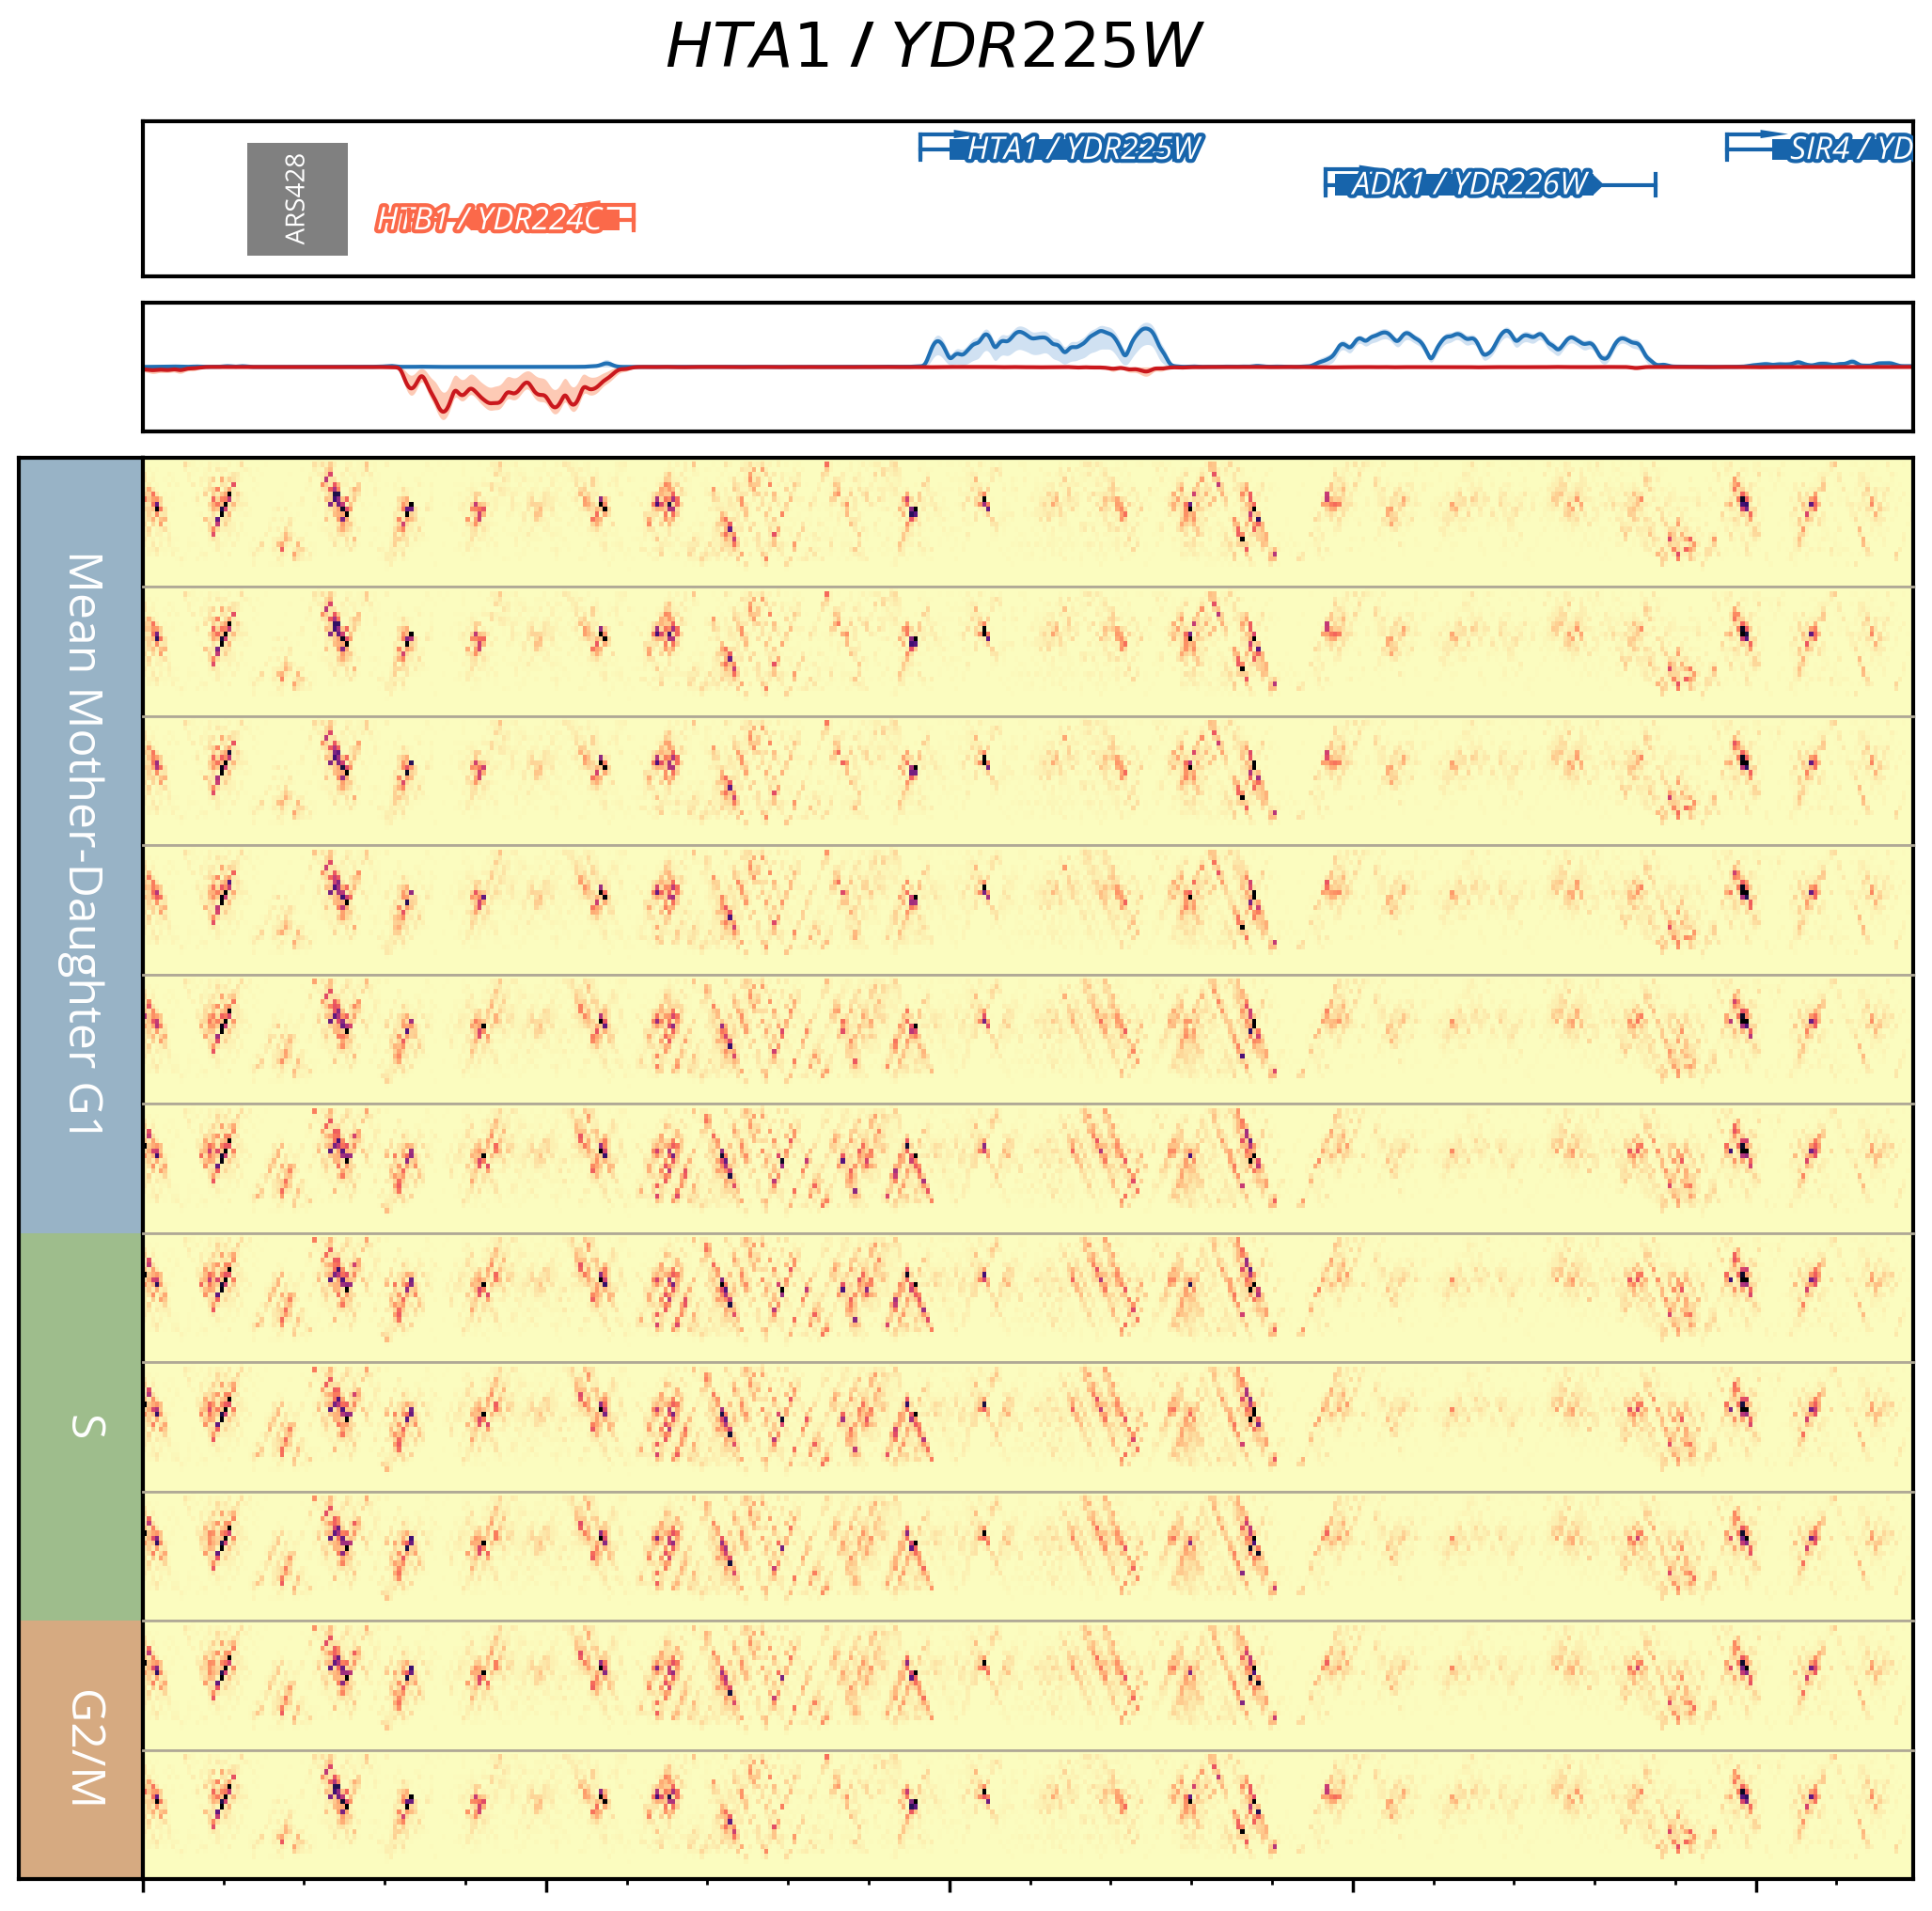

In [17]:
from src.sgd import get_gene_title_name

gene_title = get_gene_title_name(gene.name)
genome_deconv_analysis.plot_loaded_data(figsize=(13, 11), title=gene_title)

In [33]:
from pipeline.transcription_processor import ExpressionAnalysisProcessor


# Analyze the global non-genic transcripts view
output_dir = 'output/draft4_run/'
expression_processor = ExpressionAnalysisProcessor(output_dir)
expression_processor.load_deconvolved_expression()


Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 7748
Loaded expression data: 7633 transcripts, 257 timepoints


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256
transcript_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
YPR102C,9.127817,9.127801,9.127773,9.127729,9.127672,9.127623,9.127588,9.127553,9.127524,9.127520,9.127531,9.127620,9.127783,9.127865,9.127841,9.127826,9.127801,9.127631,9.127325,9.126963,9.126567,9.126256,9.126078,9.126041,9.126188,9.126578,9.127249,9.128202,9.129466,9.131130,9.133219,9.135689,9.138558,9.141887,9.145656,9.149875,9.154510,9.159361,9.164396,9.169684,...,9.396458,9.397502,9.398629,9.399857,9.401323,9.403031,9.404918,9.406991,9.409246,9.411662,9.414268,9.417039,9.419817,9.422605,9.425471,9.428404,9.431423,9.434554,9.437738,9.441007,9.444557,9.448363,9.452390,9.456620,9.460866,9.465133,9.469468,9.473852,9.478413,9.483141,9.487846,9.492527,9.497346,9.502190,9.507049,9.511691,9.515767,9.519103,9.520827,9.183663
nogene_chr16_187387_187598_0,3.506660,3.506642,3.506607,3.506555,3.506486,3.506401,3.506302,3.506185,3.506054,3.505913,3.505763,3.505618,3.505479,3.505304,3.505088,3.504858,3.504611,3.504311,3.503963,3.503584,3.503180,3.502779,3.502393,3.502021,3.501674,3.501363,3.501097,3.500875,3.500705,3.500609,3.500592,3.500642,3.500761,3.500966,3.501252,3.501620,3.502061,3.502517,3.502983,3.503475,...,3.519058,3.518418,3.517768,3.517139,3.516715,3.516495,3.516417,3.516489,3.516662,3.516920,3.517311,3.517812,3.518319,3.518836,3.519387,3.519970,3.520634,3.521380,3.522174,3.523022,3.523932,3.524897,3.525927,3.527014,3.528104,3.529204,3.530319,3.531450,3.532678,3.534000,3.535350,3.536726,3.538152,3.539590,3.541049,3.542456,3.543671,3.544658,3.545169,6.467183
nogene_chr15_617229_617818_0,1.085580,1.085691,1.085912,1.086245,1.086690,1.087256,1.087946,1.088755,1.089685,1.090748,1.091940,1.093293,1.094808,1.096402,1.098055,1.099837,1.101733,1.103673,1.105665,1.107735,1.109902,1.112247,1.114802,1.117572,1.120584,1.123860,1.127421,1.131274,1.135437,1.139951,1.144833,1.150067,1.155664,1.161653,1.168030,1.174793,1.181929,1.189378,1.197136,1.205164,...,1.570735,1.575369,1.580088,1.584838,1.589353,1.593632,1.597731,1.601637,1.605482,1.609257,1.612892,1.616396,1.619758,1.622970,1.626091,1.629114,1.631940,1.634618,1.637141,1.639554,1.642167,1.644973,1.647869,1.650864,1.653833,1.656758,1.659718,1.662677,1.665537,1.668304,1.670935,1.673434,1.675956,1.678456,1.680924,1.683258,1.685302,1.686977,1.687840,2.660551
YHL036W,4.172058,4.171846,4.171429,4.170804,4.169980,4.169007,4.167902,4.166663,4.165306,4.163856,4.162325,4.160716,4.159041,4.157316,4.155546,4.153732,4.151874,4.149974,4.148026,4.146036,4.143996,4.141862,4.139627,4.137280,4.134816,4.132264,4.129618,4.126888,4.124072,4.121092,4.117940,4.114668,4.111274,4.107709,4.103995,4.100143,4.096179,4.092243,4.088345,4.084547,...,3.853066,3.838657,3.823481,3.807655,3.791589,3.775277,3.758749,3.742007,3.724615,3.706675,3.688321,3.669605,3.651137,3.632934,3.614552,3.596051,3.577684,3.559204,3.540838,3.522325,3.501945,3.479801,3.456380,3.431711,3.406851,3.381848,3.356275,3.330335,3.303973,3.277199,3.250905,3.225037,3.198310,3.171321,3.144047,3.117798,3.094692,3.075736,3.065934,4.095825
YGR199W,4.864706,4.864695,4.864673,4.864641,4.864600,4.864548,4.864487,4.864416,4.864337,4.864253,4.864166,4.864082,4.864000,4.863906,4.863799,4.863679,4.863546,4.863407,4.863265,4.863121,4.862977,4.862828,4.862673,4.862522,4.862378,4.862231,4.862088,4.861951,4.861827,4.861740,4.861695,4.861689,4.861726,4.861794,4.861893,4.862028,4.862198,4.862388,4.862595,4.862825,...,4.849542,4.847529,4.845441,4.843327,4.841453,4.839819,4.838345,4.837044,4.835817,4.834657,4.833631,4.832714,4.831826,4.830971,4.830147,4.829355,4.828674,4.828084,4.827564,4.827100,4.826576,4.825992,4.825392,4.824767,4.824142,4.823524,4.822888,4.822247,4.821666,4.821141,4.820668,4.82024

In [53]:
expression_processor.raw_rep1_expression_data

,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150
transcript_name,,,,,,,,,,,,,,,,
YAL068C,0.143155,0.000000,0.121173,0.000000,0.129879,0.119761,0.000000,0.000000,0.000000,0.000000,0.000000,0.089282,0.000000,0.000000,0.115225,0.111519
YAL067W-A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
YAL067C,2.717313,2.006282,1.890244,3.131983,3.815317,2.709681,1.832331,1.612722,1.353145,1.540984,1.713744,1.669018,2.070476,2.201655,2.062510,1.898362
YAL065C,0.574498,0.424016,0.317897,0.359409,0.122135,0.217041,0.319512,0.000000,0.000000,0.000000,0.471738,0.083889,0.257705,0.100181,0.209078,0.000000
YAL064W-B,1.759171,1.664060,2.001752,1.495691,1.336610,1.449725,1.591959,1.686894,1.389146,1.523843,0.958232,1.645512,1.671428,1.640736,1.413226,1.580393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nogene_chr16_883764_884048,2.561344,2.492456,2.258186,2.698643,2.852386,2.277363,1.925253,1.855202,1.389146,1.760041,2.050707,2.139385,1.758712,1.651957,1.864015,2.160481
nogene_chr16_900044_900421,1.721483,2.350336,2.230215,2.220096,2.086687,1.835777,1.983123,1.613404,2.387442,1.690774,1.881963,1.998482,1.961941,1.977163,2.269629,2.408696
nogene_chr16_930038_930990,1.650661,2.134351,2.271263,2.060112,2.471035,1.820332,1.904811,1.896563,1.690422,1.934132,2.002835,1.921729,1.869361,1.968100,1.881476,1.963494


In [70]:
expression_processor.load_deconvolved_expression()

Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 5578
0/9663
200/9663
400/9663
600/9663
800/9663
1000/9663
1200/9663
1400/9663
1600/9663
1800/9663
2000/9663
2200/9663
2400/9663
2600/9663
2800/9663
3000/9663
3200/9663
3400/9663
3600/9663
3800/9663
4000/9663
4200/9663
4400/9663
4600/9663
4800/9663
5000/9663
5200/9663
5400/9663
5600/9663
Could not find deconvolved file for nogene_chr1_9422_9856, skipping
Could not find deconvolved file for nogene_chr1_12468_12812, skipping
Could not find deconvolved file for nogene_chr1_12827_16260, skipping
Could not find deconvolved file for nogene_chr1_16302_16805, skipping
Could not find deconvolved file for nogene_chr1_17114_17326, skipping
Could not find deconvolved file for nogene_chr1_17602_17777, skipping
Could not find deconvolved file for nogene_chr1_18077_19011, skipping
Could not find deconvolved file for nogene_chr1_19281_19729, skipping
Could not find deconvolved file for nogene_chr1_20858_21064, skipping

Could not find deconvolved file for nogene_chr2_246952_247727, skipping
Could not find deconvolved file for nogene_chr2_247737_248609, skipping
Could not find deconvolved file for nogene_chr2_250014_250225, skipping
Could not find deconvolved file for nogene_chr2_251679_252110, skipping
Could not find deconvolved file for nogene_chr2_254679_254948, skipping
Could not find deconvolved file for nogene_chr2_288315_288801, skipping
Could not find deconvolved file for nogene_chr2_291812_292871, skipping
Could not find deconvolved file for nogene_chr2_296437_296593, skipping
Could not find deconvolved file for nogene_chr2_300914_301138, skipping
Could not find deconvolved file for nogene_chr2_301164_301319, skipping
Could not find deconvolved file for nogene_chr2_303919_304838, skipping
Could not find deconvolved file for nogene_chr2_306309_306725, skipping
Could not find deconvolved file for nogene_chr2_307568_308859, skipping
Could not find deconvolved file for nogene_chr2_321338_321635, s

Could not find deconvolved file for nogene_chr2_137767_138088, skipping
Could not find deconvolved file for nogene_chr2_160626_161339, skipping
Could not find deconvolved file for nogene_chr2_165185_165581, skipping
Could not find deconvolved file for nogene_chr2_166049_166163, skipping
Could not find deconvolved file for nogene_chr2_166408_166851, skipping
Could not find deconvolved file for nogene_chr2_168799_168972, skipping
Could not find deconvolved file for nogene_chr2_169324_169918, skipping
Could not find deconvolved file for nogene_chr2_170031_170286, skipping
Could not find deconvolved file for nogene_chr2_171039_171165, skipping
Could not find deconvolved file for nogene_chr2_184181_184286, skipping
Could not find deconvolved file for nogene_chr2_185583_185731, skipping
Could not find deconvolved file for nogene_chr2_201729_202162, skipping
Could not find deconvolved file for nogene_chr2_209073_209204, skipping
Could not find deconvolved file for nogene_chr2_218197_219691, s

Could not find deconvolved file for nogene_chr3_156345_157093, skipping
Could not find deconvolved file for nogene_chr3_157811_158403, skipping
Could not find deconvolved file for nogene_chr3_158662_159315, skipping
Could not find deconvolved file for nogene_chr3_160826_160991, skipping
Could not find deconvolved file for nogene_chr3_162577_164164, skipping
Could not find deconvolved file for nogene_chr3_166635_166768, skipping
Could not find deconvolved file for nogene_chr3_169019_169208, skipping
Could not find deconvolved file for nogene_chr3_169471_169844, skipping
Could not find deconvolved file for nogene_chr3_172703_172978, skipping
Could not find deconvolved file for nogene_chr3_177103_177491, skipping
Could not find deconvolved file for nogene_chr3_179066_179283, skipping
Could not find deconvolved file for nogene_chr3_202798_204188, skipping
Could not find deconvolved file for nogene_chr3_204726_205014, skipping
Could not find deconvolved file for nogene_chr3_206911_208121, s

Could not find deconvolved file for nogene_chr4_118441_118660, skipping
Could not find deconvolved file for nogene_chr4_130361_130486, skipping
Could not find deconvolved file for nogene_chr4_133410_133731, skipping
Could not find deconvolved file for nogene_chr4_133984_134792, skipping
Could not find deconvolved file for nogene_chr4_135555_135698, skipping
Could not find deconvolved file for nogene_chr4_145819_146516, skipping
Could not find deconvolved file for nogene_chr4_163472_163988, skipping
Could not find deconvolved file for nogene_chr4_165171_165292, skipping
Could not find deconvolved file for nogene_chr4_178470_180007, skipping
Could not find deconvolved file for nogene_chr4_180012_181183, skipping
Could not find deconvolved file for nogene_chr4_192488_192616, skipping
Could not find deconvolved file for nogene_chr4_198681_199077, skipping
Could not find deconvolved file for nogene_chr4_212321_212484, skipping
Could not find deconvolved file for nogene_chr4_217581_218050, s

...

Could not find deconvolved file for nogene_chr15_418040_418294, skipping
Could not find deconvolved file for nogene_chr15_421876_422505, skipping
Could not find deconvolved file for nogene_chr15_437041_437431, skipping
Could not find deconvolved file for nogene_chr15_443548_444108, skipping
Could not find deconvolved file for nogene_chr15_447641_448140, skipping
Could not find deconvolved file for nogene_chr15_448892_449124, skipping
Could not find deconvolved file for nogene_chr15_461256_461630, skipping
Could not find deconvolved file for nogene_chr15_493769_493879, skipping
Could not find deconvolved file for nogene_chr15_496070_496171, skipping
Could not find deconvolved file for nogene_chr15_496681_496950, skipping
Could not find deconvolved file for nogene_chr15_502785_503183, skipping
Could not find deconvolved file for nogene_chr15_518363_518695, skipping
Could not find deconvolved file for nogene_chr15_521376_522531, skipping
Could not find deconvolved file for nogene_chr15_52

Could not find deconvolved file for nogene_chr16_162668_163019, skipping
Could not find deconvolved file for nogene_chr16_167964_168101, skipping
Could not find deconvolved file for nogene_chr16_169738_170245, skipping
Could not find deconvolved file for nogene_chr16_183843_184193, skipping
Could not find deconvolved file for nogene_chr16_187393_187590, skipping
Could not find deconvolved file for nogene_chr16_188231_188483, skipping
Could not find deconvolved file for nogene_chr16_198195_198390, skipping
Could not find deconvolved file for nogene_chr16_198723_198882, skipping
Could not find deconvolved file for nogene_chr16_210931_211206, skipping
Could not find deconvolved file for nogene_chr16_211429_211559, skipping
Could not find deconvolved file for nogene_chr16_220358_220514, skipping
Could not find deconvolved file for nogene_chr16_239457_239939, skipping
Could not find deconvolved file for nogene_chr16_243258_244199, skipping
Could not find deconvolved file for nogene_chr16_25

Could not find deconvolved file for nogene_chr16_46733_47091, skipping
Could not find deconvolved file for nogene_chr16_55758_56175, skipping
Could not find deconvolved file for nogene_chr16_56235_56436, skipping
Could not find deconvolved file for nogene_chr16_62669_63012, skipping
Could not find deconvolved file for nogene_chr16_63936_64432, skipping
Could not find deconvolved file for nogene_chr16_79509_80205, skipping
Could not find deconvolved file for nogene_chr16_80464_82221, skipping
Could not find deconvolved file for nogene_chr16_102695_102866, skipping
Could not find deconvolved file for nogene_chr16_105652_105822, skipping
Could not find deconvolved file for nogene_chr16_106434_106541, skipping
Could not find deconvolved file for nogene_chr16_107813_108140, skipping
Could not find deconvolved file for nogene_chr16_114328_114467, skipping
Could not find deconvolved file for nogene_chr16_114954_115079, skipping
Could not find deconvolved file for nogene_chr16_115310_115546, s

Could not find deconvolved file for nogene_chr16_754111_754301, skipping
Could not find deconvolved file for nogene_chr16_759196_759345, skipping
Could not find deconvolved file for nogene_chr16_766851_767334, skipping
Could not find deconvolved file for nogene_chr16_769023_769201, skipping
Could not find deconvolved file for nogene_chr16_769714_770266, skipping
Could not find deconvolved file for nogene_chr16_775960_776826, skipping
Could not find deconvolved file for nogene_chr16_780406_780845, skipping
Could not find deconvolved file for nogene_chr16_780854_781647, skipping
Could not find deconvolved file for nogene_chr16_783216_785320, skipping
Could not find deconvolved file for nogene_chr16_786817_787458, skipping
Could not find deconvolved file for nogene_chr16_789359_789555, skipping
Could not find deconvolved file for nogene_chr16_789971_790278, skipping
Could not find deconvolved file for nogene_chr16_797732_798926, skipping
Could not find deconvolved file for nogene_chr16_79

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256
transcript_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
YAL068C,1.454788e-01,1.454628e-01,1.454308e-01,1.453828e-01,1.453188e-01,1.452387e-01,1.451424e-01,1.450301e-01,1.449017e-01,1.447566e-01,1.445948e-01,1.444166e-01,1.442221e-01,1.440107e-01,1.437827e-01,1.435377e-01,1.432760e-01,1.429996e-01,1.427077e-01,1.424038e-01,1.420865e-01,1.417474e-01,1.413852e-01,1.409982e-01,1.405852e-01,1.401503e-01,1.396934e-01,1.392095e-01,1.386988e-01,1.381656e-01,1.376085e-01,1.370284e-01,1.364240e-01,1.357849e-01,1.351113e-01,1.344067e-01,1.336733e-01,1.329258e-01,1.321656e-01,1.313944e-01,...,8.846491e-02,8.708634e-02,8.562875e-02,8.410210e-02,8.253426e-02,8.092369e-02,7.927939e-02,7.760055e-02,7.584389e-02,7.402160e-02,7.214399e-02,7.021846e-02,6.831975e-02,6.644930e-02,6.455825e-02,6.265321e-02,6.075481e-02,5.883757e-02,5.692809e-02,5.499931e-02,5.287398e-02,5.056318e-02,4.811715e-02,4.553930e-02,4.293954e-02,4.032340e-02,3.764657e-02,3.493072e-02,3.217099e-02,2.936862e-02,2.661646e-02,2.390940e-02,2.111355e-02,1.829155e-02,1.544191e-02,1.270121e-02,1.028867e-02,8.309349e-03,7.285937e-03,1.319790e-01
YAL067W-A,1.477840e-09,1.477800e-09,1.477724e-09,1.477595e-09,1.477415e-09,1.477232e-09,1.477049e-09,1.476861e-09,1.476672e-09,1.476476e-09,1.476271e-09,1.476074e-09,1.475885e-09,1.475689e-09,1.475485e-09,1.475273e-09,1.475053e-09,1.474832e-09,1.474612e-09,1.474386e-09,1.474154e-09,1.473918e-09,1.473680e-09,1.473455e-09,1.473246e-09,1.473036e-09,1.472831e-09,1.472628e-09,1.472431e-09,1.472289e-09,1.472206e-09,1.472162e-09,1.472158e-09,1.472203e-09,1.472291e-09,1.472442e-09,1.472653e-09,1.472864e-09,1.473067e-09,1.473271e-09,...,1.463133e-09,1.462547e-09,1.461945e-09,1.461337e-09,1.460799e-09,1.460328e-09,1.459905e-09,1.459532e-09,1.459181e-09,1.458853e-09,1.458564e-09,1.458310e-09,1.458074e-09,1.457855e-09,1.457651e-09,1.457459e-09,1.457288e-09,1.457135e-09,1.456995e-09,1.456867e-09,1.456729e-09,1.456584e-09,1.456436e-09,1.456286e-09,1.456143e-09,1.456008e-09,1.455873e-09,1.455740e-09,1.455618e-09,1.455503e-09,1.455398e-09,1.455301e-09,1.455196e-09,1.455088e-09,1.454979e-09,1.454874e-09,1.454809e-09,1.454771e-09,1.454779e-09,1.489557e-09
YAL067C,1.330161e+00,1.329587e+00,1.328467e+00,1.326780e+00,1.324573e+00,1.322067e+00,1.319310e+00,1.316346e+00,1.313223e+00,1.309881e+00,1.306338e+00,1.302690e+00,1.298951e+00,1.295061e+00,1.291043e+00,1.286932e+00,1.282748e+00,1.278564e+00,1.274393e+00,1.270253e+00,1.266153e+00,1.261986e+00,1.257759e+00,1.253521e+00,1.249283e+00,1.245103e+00,1.241006e+00,1.237000e+00,1.233113e+00,1.229357e+00,1.225747e+00,1.222363e+00,1.219229e+00,1.216227e+00,1.213417e+00,1.210861e+00,1.208630e+00,1.207028e+00,1.206101e+00,1.205958e+00,...,2.754708e+00,2.813592e+00,2.871786e+00,2.927918e+00,2.973628e+00,3.008914e+00,3.036479e+00,3.055946e+00,3.070042e+00,3.079223e+00,3.081414e+00,3.077466e+00,3.070802e+00,3.061283e+00,3.048635e+00,3.032929e+00,3.011612e+00,2.985190e+00,2.954663e+00,2.920339e+00,2.884878e+00,2.848456e+00,2.809838e+00,2.769327e+00,2.727278e+00,2.683344e+00,2.638009e+00,2.591119e+00,2.539457e+00,2.482953e+00,2.425441e+00,2.366253e+00,2.301725e+00,2.233834e+00,2.160031e+00,2.084819e+00,2.018792e+00,1.965579e+00,1.937820e+00,6.342717e+00
YAL065C,7.133060e-01,7.128847e-01,7.120492e-01,7.107945e-01,7.091334e-01,7.071202e-01,7.047683e-01,7.020966e-01,6.991159e-01,6.958005e-01,6.921547e-01,6.882083e-01,6.839631e-01,6.794040e-01,6.745405e-01,6.693722e-01,6.639084e-01,6.581989e-01,6.522459e-01,6.460375e-01,6.395660e-01,6.327743e-01,6.256637e-01,6.182056e-01,6.104139e-01,6.023963e-01,5.941975e-01,5.857434e-01,5.770821e-01,5.683422e-01,5.595513e-01,5.506826e-01,5.417578e-01,5.327542e-01,5.236757e-01,5.14552

In [71]:
expression_processor.load_raw_expression()

In [72]:
expression_processor.raw_rep1_expression_data

,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150
transcript_name,,,,,,,,,,,,,,,,
YAL068C,0.143155,0.000000,0.121173,0.000000,0.129879,0.119761,0.000000,0.000000,0.000000,0.000000,0.000000,0.089282,0.000000,0.000000,0.115225,0.111519
YAL067W-A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
YAL067C,2.717313,2.006282,1.890244,3.131983,3.815317,2.709681,1.832331,1.612722,1.353145,1.540984,1.713744,1.669018,2.070476,2.201655,2.062510,1.898362
YAL065C,0.574498,0.424016,0.317897,0.359409,0.122135,0.217041,0.319512,0.000000,0.000000,0.000000,0.471738,0.083889,0.257705,0.100181,0.209078,0.000000
YAL064W-B,1.759171,1.664060,2.001752,1.495691,1.336610,1.449725,1.591959,1.686894,1.389146,1.523843,0.958232,1.645512,1.671428,1.640736,1.413226,1.580393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nogene_chr16_883764_884048,2.561344,2.492456,2.258186,2.698643,2.852386,2.277363,1.925253,1.855202,1.389146,1.760041,2.050707,2.139385,1.758712,1.651957,1.864015,2.160481
nogene_chr16_900044_900421,1.721483,2.350336,2.230215,2.220096,2.086687,1.835777,1.983123,1.613404,2.387442,1.690774,1.881963,1.998482,1.961941,1.977163,2.269629,2.408696
nogene_chr16_930038_930990,1.650661,2.134351,2.271263,2.060112,2.471035,1.820332,1.904811,1.896563,1.690422,1.934132,2.002835,1.921729,1.869361,1.968100,1.881476,1.963494


In [77]:
transcripts = expression_processor.all_transcripts_set
transcripts#[transcripts#.transcript_class == 'nongenic']


,transcript_class,chr,strand,start,stop,length,promoter_start,promoter_end,gene_body_start,gene_body_end
YAL068C,genic,1,-,1807,2169,362,2469,2169,2169,1669
YAL067W-A,genic,1,+,2480,2707,227,2180,2480,2480,2980
YAL067C,genic,1,-,7235,9016,1781,9316,9016,9016,8516
YAL065C,genic,1,-,11565,11951,386,12251,11951,11951,11451
YAL064W-B,genic,1,+,12046,12426,380,11746,12046,12046,12546
...,...,...,...,...,...,...,...,...,...,...
nogene_chr16_911354_911518,nongenic,16,-,911354,911518,164,911818,911518,911518,911018
nogene_chr16_916827_916941,nongenic,16,-,916827,916941,114,917241,916941,916941,916441
nogene_chr16_930146_930982,nongenic,16,-,930146,930982,836,931282,930982,930982,930482
nogene_chr16_935902_937937,nongenic,16,-,935902,937937,2035,938237,937937,937937,937437


In [74]:
expression_processor.load_raw_expression()

In [78]:
expression_processor.raw_rep1_expression_data.join(transcripts)


,0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,transcript_class,chr,strand,start,stop,length,promoter_start,promoter_end,gene_body_start,gene_body_end
transcript_name,,,,,,,,,,,,,,,,,,,,,,,,,,
YAL068C,0.099864,0.000000,0.086590,0.000000,0.093136,0.085768,0.000000,0.000000,0.000000,0.000000,0.000000,0.065129,0.000000,0.000000,0.083965,0.081175,genic,1,-,1807,2169,362,2469,2169,2169,1669
YAL067W-A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,genic,1,+,2480,2707,227,2180,2480,2480,2980
YAL067C,2.272431,1.632523,1.541556,2.698220,3.358639,2.299173,1.495999,1.301446,1.065014,1.232370,1.397891,1.365610,1.725517,1.844691,1.718068,1.567855,genic,1,-,7235,9016,1781,9316,9016,9016,8516
YAL065C,0.418008,0.307823,0.231474,0.263011,0.087518,0.156899,0.234168,0.000000,0.000000,0.000000,0.353183,0.061164,0.190281,0.072816,0.153679,0.000000,genic,1,-,11565,11951,386,12251,11951,11951,11451
YAL064W-B,1.399806,1.327664,1.642184,1.193166,1.056565,1.154050,1.282193,1.367136,1.095950,1.217381,0.745205,1.344646,1.364756,1.336266,1.136756,1.283075,genic,1,+,12046,12426,380,11746,12046,12046,12546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nogene_chr16_911354_911518,0.962900,1.083778,1.731686,1.676507,1.468001,1.779754,1.912728,1.267651,1.963228,1.342180,0.177050,0.384923,0.413412,0.449462,0.179229,0.173457,nongenic,16,-,911354,911518,164,911818,911518,911518,911018
nogene_chr16_916827_916941,0.750843,1.268612,1.247909,2.056556,1.987187,2.106540,1.920144,1.861015,1.942551,1.769573,1.616454,1.539168,1.282212,1.264399,1.537521,0.451628,nongenic,16,-,916827,916941,114,917241,916941,916941,916441
nogene_chr16_930146_930982,1.386167,1.829121,2.009604,1.791721,2.149350,1.579783,1.652006,1.657169,1.422478,1.648797,1.724768,1.659719,1.654516,1.677628,1.621031,1.724975,nongenic,16,-,930146,930982,836,931282,930982,930982,930482
